# Lab 6 Applications of Queing Models

### Exercise 1-1
#### Theoretical Vs Simulated throughput comparison of multiple access protocols


Multi-access communication systems involve several stations or mobile terminals sharing the same transmission medium. Each station can generate packets independently, store them in a local queue, and then attempt to transmit them over the common channel. Since the stations are distributed, one station usually does not know how much traffic is waiting at the other stations.

ALOHA is a simple random access protocol used to study this type of shared-channel behaviour. In ALOHA, packets are transmitted whenever they are generated, without checking whether another station is already transmitting. If two or more packets overlap in time, a collision occurs and the affected packets are not successfully received.

In this lab, packet arrivals are modelled as a Poisson process with arrival rate $\lambda$. This means that the inter-arrival time between packets follows an exponential distribution. Packet transmission times are assumed to be independent and exponentially distributed with parameter $\mu$. The traffic intensity, or offered load, is given by:

$$
A = \frac{\lambda}{\mu}
$$

The collision behaviour of ALOHA can be related to an $M/M/\infty$ queueing model. A newly arriving packet can collide with any packet that is already being transmitted. Therefore, the probability that a packet does not collide with previous packets is equivalent to the probability that the $M/M/\infty$ system is empty. For an $M/M/\infty$ system, the steady-state probability of having $n$ packets in service is:

$$
\pi_n = \frac{A^n}{n!}e^{-A}, \qquad n = 0,1,2,\ldots
$$

Therefore, the probability that the system is empty is:

$$
 \pi_0 = e^{-A}
$$

For a packet to avoid collision completely, it must also finish transmission before the next packet arrives. The probability that the immediate successor does not arrive during the packet’s transmission time OR the next event is NOT an arrival during the packet's transmission time is:

$$
\frac{\mu}{\lambda + \mu}
$$

Hence, the probability of no collision is:

$$
P_{\text{no collision}} = \pi_0 \frac{\mu}{\lambda + \mu}
$$

Substituting $\pi_0 = e^{-A}$ gives:

$$
P_{\text{no collision}} = e^{-A}\frac{\mu}{\lambda + \mu}
$$

This lab uses simulation to investigate the effect of offered load on collisions and throughput in pure ALOHA and slotted ALOHA systems.

Reference: Moshe Zukkermann, "Introduction to Queueing Theory and Stochastic Teletraffic Models" 

\url{https://arxiv.org/abs/1307.2968}


### Questions
1. Complete the code for the slotted ALOHA and pure ALOHA functions below.

DONE

2. Run the code and check whether the theoretical throughput curves match the simulation results.

DONE. Yes they match.

3. Can this system be analysed using Markovian queueing models? Briefly explain your answer.

Yes. The arrival process is Poisson and the interarrival times are exponentially distributed. The packet service times are also independent and exponentially distributed. So they are all MArkovian, and we can use Markovian queueing models to analyse the system.


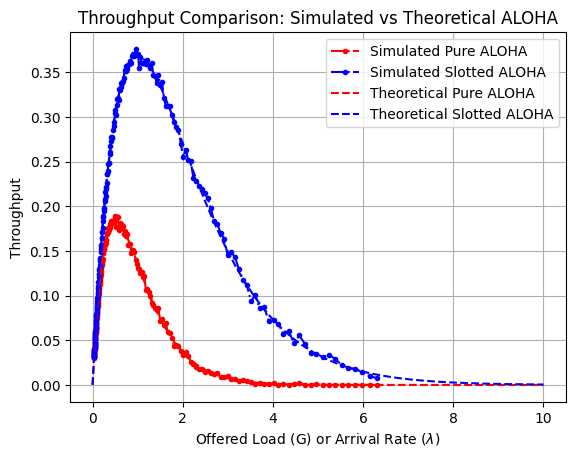

In [30]:
#Reference https://gist.github.com/arunsammit/da15a99164ac616c019fd92c290bcc27

PACKET_TIME = 1.0

import matplotlib.pyplot as plt
import numpy as np
import math

def slotted_aloha(arrival_times: np.ndarray):
    """
    Slotted ALOHA success calculation.

    In slotted ALOHA, time is divided into slots of length PACKET_TIME.
    A packet is successful if it is the only packet transmitted in that slot.
    """

    
    # Create an array to count how many packets arrive in each slot.
    # Hint: the number of slots can be based on math.ceil(arrival_times[-1]) + 1.
    count_arrivals = np.zeros(math.ceil(arrival_times[-1]) + 1)

    for val in arrival_times:
        
        # Convert the arrival time val into a slot number using math.ceil(val),
        # then increase the count for that slot by 1.
        count_arrivals[math.ceil(val) - 1] += 1

    # Return the number of slots that contain exactly one packet.
    # These represent successful slotted ALOHA transmissions.
    return np.sum(count_arrivals == 1)


def pure_aloha(arrival_times: np.ndarray):
    """
    Pure ALOHA success calculation.

    In pure ALOHA, a packet is successful only if there is no packet arriving
    within one packet time before it or one packet time after it.
    """

    success = 0
    N = len(arrival_times)

    # Calculate the time differences between consecutive packet arrivals.
    inter_arrival_time = np.diff(arrival_times)

    for j in range(N):
        # Check whether the previous packet is far enough away.
        # For the first packet, there is no previous packet, so previous_clear is True.
        previous_clear = j == 0 or inter_arrival_time[j - 1] >= PACKET_TIME

        
        # Check whether the next packet is far enough away.
        # For the last packet, there is no next packet, so next_clear is True.
        next_clear = j == N - 1 or inter_arrival_time[j] >= PACKET_TIME

        # If both previous_clear and next_clear are true,
        # count this packet as a successful transmission.
        if previous_clear and next_clear:
            success += 1

    return success

# Parameters for simulation
N = 10000
numG = 200
rng = np.random.default_rng()
throughput_pure_sim = np.zeros(numG)
throughput_slotted_sim = np.zeros(numG)
G = np.logspace(-1.5, .8, numG) # array of load values, lambdas

# Compute throughput for different values of G (simulations)
for i, lam in enumerate(G):
    inter_arrival_time = rng.exponential(1 / lam, N)
    arrival_times = np.cumsum(inter_arrival_time)
    throughput_pure_sim[i] = pure_aloha(arrival_times) / math.ceil(arrival_times[-1])
    throughput_slotted_sim[i] = slotted_aloha(arrival_times) / math.ceil(arrival_times[-1])

# Theoretical throughput calculation
lambda_values = np.linspace(0, 10, 200)
throughput_slotted_theoretical = lambda_values * np.exp(-lambda_values)   # complete the equation
throughput_pure_theoretical = lambda_values * np.exp(-2 * lambda_values)  # complete the equation

# Plot the comparison
fig, ax = plt.subplots()
# Plot simulation results
ax.plot(G, throughput_pure_sim, marker='.', label='Simulated Pure ALOHA', color='red',linestyle='-.')
ax.plot(G, throughput_slotted_sim, marker='.', label='Simulated Slotted ALOHA', color='blue',linestyle='-.')
# Plot theoretical results
ax.plot(lambda_values, throughput_pure_theoretical, label='Theoretical Pure ALOHA', color='red', linestyle='--')
ax.plot(lambda_values, throughput_slotted_theoretical, label='Theoretical Slotted ALOHA', color='blue', linestyle='--')
ax.set_xscale('linear')
ax.set_xlabel('Offered Load (G) or Arrival Rate ($\lambda$)')
ax.set_ylabel('Throughput')
ax.set_title('Throughput Comparison: Simulated vs Theoretical ALOHA')
ax.grid(True)
ax.legend()
plt.show()


### Exercise 1-2
4. For pure ALOHA, compare the theoretical probability of no collision with the probability of no collision obtained from the simulation. How closely do they match?

They do not match. The theoretical probability of NO collision is significantly higher than what we found in the pure ALOHA simulation.

5. Discuss the result in terms of low and high load conditions.

The differences are greater for higher loads, and as the load increases the probability of no collision in all 3 cases becomes 0 eventually.

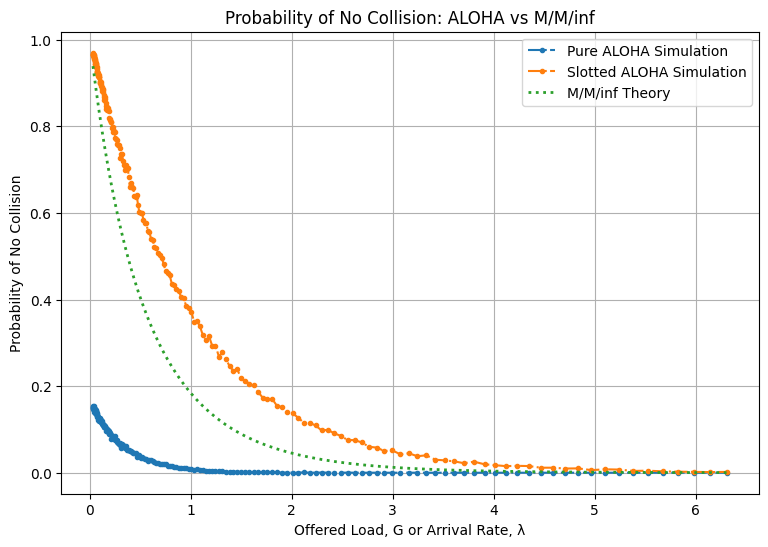

In [3]:
# Simulation parameters
prob_no_collision_pure_sim = np.zeros(numG)
prob_no_collision_slotted_sim = np.zeros(numG)
prob_no_collision_pure_theory = np.zeros(numG)
prob_no_collision_slotted_theory = np.zeros(numG)
prob_no_collision_mminf_theory = np.zeros(numG)
mu = 1.0 / PACKET_TIME  # based on your packet time input the service rate
for i, lam in enumerate(G):
    inter_arrival_time = rng.exponential(1 / lam, N)
    arrival_times = np.cumsum(inter_arrival_time)

    pure_success = pure_aloha(inter_arrival_time)
    slotted_success = slotted_aloha(arrival_times)

    prob_no_collision_pure_sim[i] = pure_success / N
    prob_no_collision_slotted_sim[i] = slotted_success / N

    # M/M/inf theory
    A = lam / mu
    prob_no_collision_mminf_theory[i] = math.exp(-A) * (mu / (lam + mu))
    
# Plot comparison
plt.figure(figsize=(9, 6))

plt.plot(
    G,
    prob_no_collision_pure_sim,
    marker='.',
    linestyle='-.',
    label='Pure ALOHA Simulation'
)

plt.plot(
    G,
    prob_no_collision_slotted_sim,
    marker='.',
    linestyle='-.',
    label='Slotted ALOHA Simulation'
)

plt.plot(
    G,
    prob_no_collision_mminf_theory,
    linestyle=':',
    linewidth=2,
    label='M/M/inf Theory'
)

plt.xlabel('Offered Load, G or Arrival Rate, λ')
plt.ylabel('Probability of No Collision')
plt.title('Probability of No Collision: ALOHA vs M/M/inf')
plt.grid(True)
plt.legend()
plt.show()

### Exercise 2
Shared-channel ALOHA network with multiple packet-generating nodes is explored in this exercise. Each node independently generates packets using exponentially distributed inter-arrival times, which models random packet arrivals. All packet arrivals are combined into one shared channel, where collisions may occur if packets are transmitted too close together in time.

The code compares pure ALOHA and slotted ALOHA by calculating the probability of no collision under two conditions. In the first experiment, the arrival rate per node is kept fixed while the number of nodes increases. In the second experiment, the total arrival rate is kept fixed while the number of nodes changes. This allows students to observe whether ALOHA performance depends mainly on the number of nodes or on the total offered load.

**Questions**
1. Complete the missing parts of the code.

DONE

2. For the fixed arrival rate per node experiment, what happens to the probability of no collision as the number of nodes increases?

It decreases

3. For the fixed total arrival rate experiment, does the number of nodes have the same effect? Explain why or why not.

No, as we change the number of notes, the probability of no collision stays relatively constant. The overall traffic in the shared medium is not changing, so there is no reason that the probability of collisions would change.

4. Explain the difference between per-node arrival rate and total offered load.

One is per node and one is to the entire system.

5. Based on your plots, does ALOHA performance depend mainly on the number of nodes or on the total offered load? Explain your answer.

Mainly on the total offered load, not the number of nodes. When we changed the number of nodes with fixed arrival rate per node, we increased the total traffic and increased the chance of collisions. Then when we changed the number of nodes while keeping total traffic constant, there was no change.

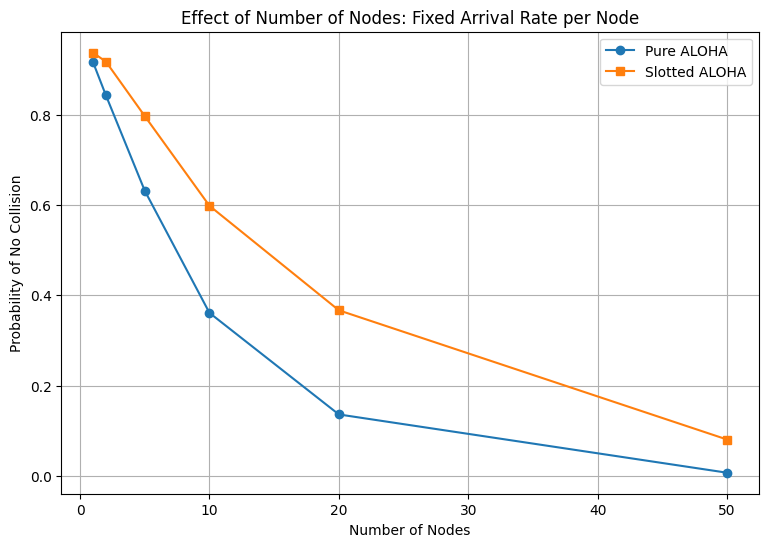

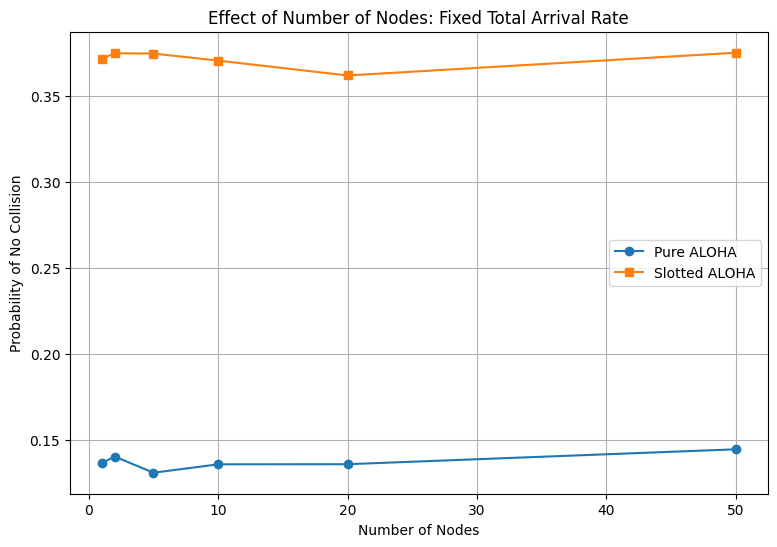

Fixed arrival rate per node
Nodes	G
1	0.048
2	0.100
5	0.245
10	0.505
20	0.999
50	2.509

Fixed total arrival rate
Nodes	G
1	1.000
2	0.994
5	1.017
10	0.990
20	1.008
50	0.988


In [4]:
import simpy
import random
import math
import numpy as np
import matplotlib.pyplot as plt


SIM_TIME = 10000
PACKET_TIME = 1.0


def packet_generator(env, node_id, arrival_rate, all_arrival_times):
    """
    Packet generator for one node.

    Each node generates packets with exponentially distributed inter-arrival times.
    The generated arrival time and node ID are stored in all_arrival_times.
    """

    while True:
        # Generate the next inter-arrival time using an exponential distribution.
        # Hint: use random.expovariate(arrival_rate)
        interarrival_time = random.expovariate(arrival_rate)

        # Advance the SimPy simulation clock by the generated inter-arrival time.
        yield env.timeout(interarrival_time)

        # If the current simulation time is still less than SIM_TIME,
        # record the packet arrival time and the node ID.
        if env.now < SIM_TIME:
            all_arrival_times.append((env.now, node_id))


def generate_arrivals_packet_generators(num_nodes, arrival_rate_per_node):
    """
    Create multiple packet generators.

    Each node runs its own packet generator, but all generated packets are placed
    into one shared list. This represents a shared ALOHA channel.
    """

    env = simpy.Environment()
    all_arrival_times = []

    
    # Use a loop to create one packet generator for each node.
    # The node IDs should start at 1 and end at num_nodes.
    for node_id in range(1, num_nodes + 1):
        env.process(packet_generator(
            env,
            node_id=node_id,
            arrival_rate=arrival_rate_per_node,
            all_arrival_times=all_arrival_times
        ))

    # Run the simulation until SIM_TIME.
    env.run(until=SIM_TIME)

    
    # Sort all packet arrivals by arrival time.
    # Hint: each item is stored as (arrival_time, node_id).
    all_arrival_times.sort(key=lambda x: x[0])

    
    # Extract the arrival times and node IDs into two separate NumPy arrays.
    arrival_times = np.array([x[0] for x in all_arrival_times])
    node_ids = np.array([x[1] for x in all_arrival_times])

    return arrival_times, node_ids


# def slotted_aloha(arrival_times: np.ndarray):



# def pure_aloha(arrival_times: np.ndarray):



# Different numbers of nodes to test
node_values = [1, 2, 5, 10, 20, 50]

pure_P_fixed_per_node = []
slotted_P_fixed_per_node = []

pure_P_fixed_total = []
slotted_P_fixed_total = []

G_fixed_per_node = []
G_fixed_total = []


random.seed(42)

# ---------------------------------------------------------
# Experiment 1: Fixed arrival rate per node
# ---------------------------------------------------------
# In this experiment, each node sends packets at the same rate.
# As the number of nodes increases, the total offered load increases.

arrival_rate_per_node_fixed = 0.05

for num_nodes in node_values:

    
    # Generate arrival times for the current number of nodes.
    arrival_times, node_ids = generate_arrivals_packet_generators(
        num_nodes,
        arrival_rate_per_node_fixed
    )

    # Calculate the total number of attempted transmissions.
    attempts = len(arrival_times)
    
    # Calculate successful transmissions for pure ALOHA and slotted ALOHA.
    pure_successes = pure_aloha(arrival_times)
    slotted_successes = slotted_aloha(arrival_times)

    
    # Calculate the total offered load G.
    # Hint: G = attempts * PACKET_TIME / SIM_TIME
    G = attempts * PACKET_TIME / SIM_TIME

    
    # Calculate and store the probability of no collision.
    # Hint: probability of no collision = successful packets / attempted packets
    pure_P_fixed_per_node.append(pure_successes / attempts)
    slotted_P_fixed_per_node.append(slotted_successes / attempts)

    G_fixed_per_node.append(G)


random.seed(42)

# ---------------------------------------------------------
# Experiment 2: Fixed total arrival rate
# ---------------------------------------------------------
# In this experiment, the total traffic load is kept fixed.
# As the number of nodes increases, the arrival rate per node decreases.

total_arrival_rate_fixed = 1.0

for num_nodes in node_values:

    
    # Calculate the arrival rate per node so that total arrival rate remains fixed.
    arrival_rate_per_node = total_arrival_rate_fixed / num_nodes

    arrival_times, node_ids = generate_arrivals_packet_generators(
        num_nodes,
        arrival_rate_per_node
    )

    attempts = len(arrival_times)

    pure_successes = pure_aloha(arrival_times)
    slotted_successes = slotted_aloha(arrival_times)

    G = attempts * PACKET_TIME / SIM_TIME

    pure_P_fixed_total.append(pure_successes / attempts)
    slotted_P_fixed_total.append(slotted_successes / attempts)

    G_fixed_total.append(G)


# ---------------------------------------------------------
# Plot 1: Fixed arrival rate per node
# ---------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.plot(node_values, pure_P_fixed_per_node, marker="o", label="Pure ALOHA")
plt.plot(node_values, slotted_P_fixed_per_node, marker="s", label="Slotted ALOHA")

plt.xlabel("Number of Nodes")
plt.ylabel("Probability of No Collision")
plt.title("Effect of Number of Nodes: Fixed Arrival Rate per Node")
plt.grid(True)
plt.legend()
plt.show()


# ---------------------------------------------------------
# Plot 2: Fixed total arrival rate
# ---------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.plot(node_values, pure_P_fixed_total, marker="o", label="Pure ALOHA")
plt.plot(node_values, slotted_P_fixed_total, marker="s", label="Slotted ALOHA")

plt.xlabel("Number of Nodes")
plt.ylabel("Probability of No Collision")
plt.title("Effect of Number of Nodes: Fixed Total Arrival Rate")
plt.grid(True)
plt.legend()
plt.show()


# ---------------------------------------------------------
# Print offered load values
# ---------------------------------------------------------

print("Fixed arrival rate per node")
print("Nodes\tG")

for nodes, G in zip(node_values, G_fixed_per_node):
    print(f"{nodes}\t{G:.3f}")


print("\nFixed total arrival rate")
print("Nodes\tG")

for nodes, G in zip(node_values, G_fixed_total):
    print(f"{nodes}\t{G:.3f}")

### Exercise 3

### Exercise 3
## Lab Exercise: Erlang B Recursion and Blocking Probability

In this lab, you will investigate the Erlang B formula (M/M/k/k) that was discussed in Week 8, which is used to calculate the blocking probability in a loss system. A loss system is a system where an arriving call or packet is blocked if all available channels are already occupied. In this case, blocked traffic is not queued; it is simply rejected.

The direct Erlang B formula contains factorial terms. These factorials can become difficult to compute when the number of channels is large. To avoid this problem, we use a recursive form of the Erlang B equation.

Let $E_m(A)$ represent the blocking probability when the traffic intensity is $A$ Erlangs and the system has $m$ channels. The recursive relationship is given by (see derivation below):

$$
E_m(A) = \frac{A E_{m-1}(A)}{m + A E_{m-1}(A)}
$$

where:

$$
m = 1, 2, \ldots, k
$$

The recursion starts with:

$$
E_0(A) = 1
$$

This recursive method is useful because it avoids direct calculation of large factorials and provides a simple way to calculate the blocking probability for different numbers of channels.

In this lab, you will implement the recursive Erlang B formula in Python. You will then plot the blocking probability against traffic intensity for different numbers of channels. Finally, you will use the results to determine the maximum traffic intensity that can be supported for a given number of channels and a required Grade of Service.

The Grade of Service, or GOS, is represented by the target blocking probability. For example, a GOS of $0.01$ means that the system should block no more than 1% of arriving calls or packets.

## Derivation of the Erlang B Recursive Formula

The Erlang B formula gives the blocking probability for a loss system with offered traffic intensity $A$ and $m$ channels:

$$
E_m(A) =
\frac{\dfrac{A^m}{m!}}
{\sum_{j=0}^{m} \dfrac{A^j}{j!}}
$$

Similarly, for a system with $m-1$ channels:

$$
E_{m-1}(A) =
\frac{\dfrac{A^{m-1}}{(m-1)!}}
{\sum_{j=0}^{m-1} \dfrac{A^j}{j!}}
$$

We want to derive a recursive formula that relates $E_m(A)$ to $E_{m-1}(A)$.

Start by rewriting the denominator of $E_m(A)$:

$$
\sum_{j=0}^{m} \frac{A^j}{j!}
=
\sum_{j=0}^{m-1} \frac{A^j}{j!}
+
\frac{A^m}{m!}
$$

Using the expression for $E_{m-1}(A)$, we can rearrange:

$$
E_{m-1}(A) =
\frac{\dfrac{A^{m-1}}{(m-1)!}}
{\sum_{j=0}^{m-1} \dfrac{A^j}{j!}}
$$

Therefore:

$$
\sum_{j=0}^{m-1} \frac{A^j}{j!}
=
\frac{\dfrac{A^{m-1}}{(m-1)!}}{E_{m-1}(A)}
$$

Substitute this into the Erlang B formula for $E_m(A)$:

$$
E_m(A) =
\frac{\dfrac{A^m}{m!}}
{
\frac{\dfrac{A^{m-1}}{(m-1)!}}{E_{m-1}(A)}
+
\dfrac{A^m}{m!}
}
$$

Now use the identity:

$$
\frac{A^m}{m!}
=
\frac{A}{m}
\frac{A^{m-1}}{(m-1)!}
$$

So:

$$
E_m(A) =
\frac{\dfrac{A}{m}\dfrac{A^{m-1}}{(m-1)!}}
{
\frac{\dfrac{A^{m-1}}{(m-1)!}}{E_{m-1}(A)}
+
\dfrac{A}{m}\dfrac{A^{m-1}}{(m-1)!}
}
$$

Cancel the common factor $\dfrac{A^{m-1}}{(m-1)!}$:

$$
E_m(A) =
\frac{\dfrac{A}{m}}
{
\frac{1}{E_{m-1}(A)}
+
\dfrac{A}{m}
}
$$

Multiply the numerator and denominator by $mE_{m-1}(A)$:

$$
E_m(A) =
\frac{A E_{m-1}(A)}
{m + A E_{m-1}(A)}
$$

Therefore, the recursive Erlang B formula is:

$$
E_m(A) =
\frac{A E_{m-1}(A)}
{m + A E_{m-1}(A)}
$$

with the initial condition:

$$
E_0(A) = 1
$$

This recursion is useful because it avoids directly calculating large factorials in the original Erlang B formula.




Reference: https://arxiv.org/abs/1307.2968

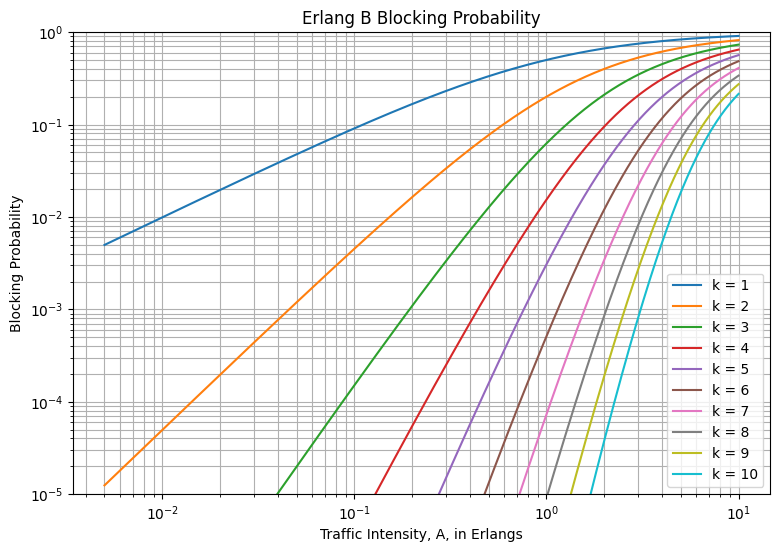

Traffic intensity for 7 channels with a GOS of 0.05 is approximately 3.735 Erlangs.


In [16]:
import numpy as np
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# Lab Exercise: Erlang B Blocking Probability
# ---------------------------------------------------------
# This exercise investigates how blocking probability changes with:
# 1. traffic intensity, A
# 2. number of channels, k
#
# The Erlang B model is used when blocked calls or packets are cleared,
# meaning they do not wait in a queue.
# ---------------------------------------------------------



# Create an array of traffic intensity values from 0.005 to 10.
# Use np.arange(start, stop, step).
A_values = np.arange(0.005, 10.005, 0.005)



# Create an array for the number of channels from 1 to 10.
# Hint: use np.arange(1, 11)
k_vec = np.arange(1, 11)


# Create a 2D array of zeros to store Erlang B blocking probabilities.
# The number of rows should match len(A_values).
# The number of columns should match len(k_vec).
Ek_values = np.zeros((len(A_values), len(k_vec)))


# ---------------------------------------------------------
# Erlang B recursive equation
# ---------------------------------------------------------

def erlang_B(A, k, Em):
    """
    Calculate Erlang B recursively.

    A  = traffic intensity in Erlangs
    k  = number of channels
    Em = previous Erlang B value
    """

    # TODO 4:
    # Complete the recursive Erlang B formula:
    #
    # E_k = (A * E_{k-1}) / (k + A * E_{k-1})
    #

    if k == 0:
        return 1.0  # E_0 is defined to be 1
    else:
        return (A * erlang_B(A, k - 1, Em)) / (k + A * erlang_B(A, k - 1, Em))
    
    # return (A * Em) / (k + A * Em)


# ---------------------------------------------------------
# Calculate Erlang B blocking probabilities
# ---------------------------------------------------------

for i, A in enumerate(A_values):
    # Initialise Em to 1 before calculating blocking probabilities
    # for each value of k.
    Em = 1.0

    for k_loop, k in enumerate(k_vec):

        
        # Update Em using the erlang_B function.
        Em = erlang_B(A, k, Em)

        
        # Store the calculated value in Ek_values.
        Ek_values[i, k_loop] = Em


# ---------------------------------------------------------
# Plot Erlang B curves
# ---------------------------------------------------------

plt.figure(figsize=(9, 6))

for pt in range(len(k_vec)):

    
    # Plot blocking probability versus traffic intensity on a log-log scale.
    # Hint: use plt.loglog(x_values, y_values, label=...)
    plt.loglog(A_values, Ek_values[:, pt], label=f'k = {k_vec[pt]}')


plt.xlabel('Traffic Intensity, A, in Erlangs')
plt.ylabel('Blocking Probability')
plt.title('Erlang B Blocking Probability')
plt.ylim(1e-5, 1)
plt.grid(True, which='both')
plt.legend()
plt.show()


# ---------------------------------------------------------
# Find supported traffic intensity for a given blocking threshold
# ---------------------------------------------------------

#enter the number of channels.

C = 7


#  enter the blocking probability threshold.
# Convert the input to a float.
P_B = 0.05

# Convert the channel number C into the correct column index.
# Remember: Python indexing starts from 0.
column_index = C - 1



# Find all values of A where the blocking probability is less than
# or equal to the threshold P_B.
# Hint: use np.where(Ek_values[:, column_index] <= P_B)[0]
valid_indices = np.where(Ek_values[:, column_index] <= P_B)[0]



# Check whether any valid traffic intensity values were found. YUse this code for answering the question.
if len(valid_indices) == 0:
    print(f'No traffic intensity in the tested range satisfies P_B <= {P_B} for k = {C}.')

else:
    
    # Select the largest valid index.
    Indx = valid_indices[-1]

    
    # Print the maximum supported traffic intensity.
    print(
        f'Traffic intensity for {C} channels with a GOS of {P_B} '
        f'is approximately {A_values[Indx]:.3f} Erlangs.'
    )

### Exercise 4: Erlang B and Erlang C for Large Traffic Loads

In this part, you will investigate how the recursive Erlang B formula can be used to calculate the minimum number of channels required for a given traffic intensity and blocking probability requirement.

The Erlang B model is used for **loss systems**, where an arriving call or packet is blocked if all channels are already occupied. Blocked traffic is not queued. The recursive Erlang B formula is useful because it avoids the direct calculation of large factorial terms when the number of channels is large.

The recursive Erlang B equation is:

$$
E_m(A) = \frac{A E_{m-1}(A)}{m + A E_{m-1}(A)}
$$

where:

- $A$ is the offered traffic intensity in Erlangs.
- $m$ is the number of channels.
- $E_m(A)$ is the Erlang B blocking probability for $m$ channels.
- The recursion starts with $E_0(A) = 1$.

After calculating the minimum number of channels needed to achieve a target blocking probability, you will also calculate Erlang C. Erlang C is used for **waiting systems**, where arriving calls or packets may wait in a queue instead of being immediately blocked.

The Erlang C equation used in this lab is:

$$
C_k(A) =
\frac{\frac{k}{k-A}}
{\frac{1-E_k}{E_k} + \frac{k}{k-A}}
$$

where:

- $k$ is the number of channels.
- $A$ is the offered traffic intensity.
- $E_k$ is the Erlang B blocking probability for $k$ channels.
- Erlang C gives the probability that an arriving call or packet has to wait.

In this lab, you will complete the Python code to:

1. calculate Erlang B recursively;
2. find the minimum number of channels needed to achieve a blocking probability of $0.01$ or lower;
3. calculate the utilisation percentage;
4. calculate Erlang C using the Erlang B result;
5. compare the results for different offered traffic intensities.

**Questions**

1. Complete all missing parts of the Python code.

2. Why is the recursive Erlang B formula preferred over the direct Erlang B formula when the number of channels is large?

So that we don't need to compute large factorials which is copmputationally expensive.
    
3. What is the main difference between Erlang B and Erlang C?

Erlang B is the blocking probability in a M/M/k/k system, where if there is no space to serve a packet it is simply blocked. Erlang C is the proportion of time that all k servers in an M/M/k system are busy, but in this system no packets are blocked and they will wait in a queue until they are served.

4. What is the condition for  $k$ and $A$ when calculating Erlang C?

We want A/k to be < 1 when calculating Erlang C, other wise we will get a result greater than 1 which doesn't make sense, the system is unstable.

5. What happens to the required number of channels as $A$ becomes very large?

As A increases, the number of required channels also increases.

6. Based on your results, explain the trade-off between traffic intensity, number of channels, blocking probability, and utilisation.

Higher traffic intensity leads to increased chance of a packet being blocked, and also higher utilisation of the available servers. Increasing number of channels can decrease the utilisation and blocking probability to help the system cope with increased traffic.

In [17]:
import numpy as np
import pandas as pd


# ---------------------------------------------------------
# Erlang B recursive equation
# ---------------------------------------------------------

def erlang_B(A, k, Em):
    """
    Calculate Erlang B recursively.

    A  = traffic intensity in Erlangs
    k  = number of channels
    Em = previous Erlang B value
    """

    # TODO 4:
    # Complete the recursive Erlang B formula:
    #
    # E_k = (A * E_{k-1}) / (k + A * E_{k-1})
    #

    # if k == 0:
    #     return 1.0  # E_0 is defined to be 1
    # else:
    #     return (A * erlang_B(A, k - 1, Em)) / (k + A * erlang_B(A, k - 1, Em))

    return (A * Em) / (k + A * Em)

# ---------------------------------------------------------
# Erlang C equation -COMPLETE
# ---------------------------------------------------------

def erlangC_Eqn(A, k, E_k):
    """
    Calculate Erlang C using the Erlang B result.

    A   = offered traffic intensity in Erlangs
    k   = number of channels
    E_k = Erlang B blocking probability for k channels
    """

    # Complete the numerator of the Erlang C equation.
    numerator = k / (k - A)

    # TODO 3:
    # Complete the denominator of the Erlang C equation.
    erlang_B_val = erlang_B(A, k, E_k)
    denominator = (1 - erlang_B_val) / erlang_B_val + numerator

    # TODO 4:
    # Return Erlang C.
    return numerator / denominator


# ---------------------------------------------------------
# Traffic intensity values
# ---------------------------------------------------------

# These are the offered traffic intensities in Erlangs. We will use these numbers so 
#that we can confirm against the values in the textbook page 179 https://arxiv.org/abs/1307.2968
A_values = np.array([20, 100, 500, 1000, 5000, 10000])


# ---------------------------------------------------------
# Initialise arrays to store results
# ---------------------------------------------------------
# Create an array of zeros to store the minimum number of channels
# required for each traffic intensity.
minimal_k_values = np.zeros(len(A_values))
# Create an array of zeros to store the Erlang B blocking probability.
Ek_values = np.zeros(len(A_values))
# Create an array of zeros to store the utilisation percentage.
utilization_values = np.zeros(len(A_values))


# ---------------------------------------------------------
# Calculate minimum number of channels for each A value
# ---------------------------------------------------------

for i, A in enumerate(A_values):

    # Start with zero channels.
    k = 0

    # The recursive Erlang B calculation starts with E_0(A) = 1.
    E_m = 1.0
    
    # Keep increasing k until the Erlang B blocking probability
    # becomes less than or equal to 0.01.
    while E_m > 0.01:

        # Increase the number of channels by 1.
        k = k + 1

        # Update E_m using the Erlang B recursive equation.
        E_m = erlang_B(A, k, E_m)
    
    # Store the minimum number of channels.
    minimal_k_values[i] = k

    # Store the final Erlang B blocking probability.
    Ek_values[i] = E_m

    # Calculate and store the utilisation percentage.
    #
    # Utilisation percentage:
    # carried traffic / available channels x 100
    #
    # carried traffic = A * (1 - E_k)
    utilization_values[i] = (A * (1 - E_m)) / k * 100


# ---------------------------------------------------------
# Create Table 1
# ---------------------------------------------------------

T1 = pd.DataFrame({
    'A': A_values,
    'Minimal_k': minimal_k_values,
    'Blocking_Probability': Ek_values,
    'Utilization Percentage': utilization_values
})


# ---------------------------------------------------------
# Calculate Erlang C for each A value
# ---------------------------------------------------------

# TODO 14:
# Create an array of zeros to store Erlang C values.
C_k = np.zeros(len(A_values))

for i, A in enumerate(A_values):


    # Calculate Erlang C using A, the minimum k value,
    # and the Erlang B blocking probability.
    C_k[i] = erlangC_Eqn(A, int(minimal_k_values[i]), Ek_values[i])


# ---------------------------------------------------------
# Create Table 2
# ---------------------------------------------------------

T2 = pd.DataFrame({
    'A': A_values,
    'Minimal_k': minimal_k_values,
    'Erlang B Blocking_Probability': np.round(Ek_values, 4),
    'Erlang C': np.round(C_k, 4)
})


# ---------------------------------------------------------
# Display the tables
# ---------------------------------------------------------

print("Table 1:")
print(T1)

print("\nTable 2:")
print(T2)

Table 1:
       A  Minimal_k  Blocking_Probability  Utilization Percentage
0     20       30.0              0.008457               66.102833
1    100      117.0              0.009790               84.633327
2    500      527.0              0.009539               93.971586
3   1000     1029.0              0.009942               96.215560
4   5000     5010.0              0.009966               98.805816
5  10000     9970.0              0.009931               99.304773

Table 2:
       A  Minimal_k  Erlang B Blocking_Probability  Erlang C
0     20       30.0                         0.0085    0.0166
1    100      117.0                         0.0098    0.0545
2    500      527.0                         0.0095    0.1501
3   1000     1029.0                         0.0099    0.2553
4   5000     5010.0                         0.0100    0.8329
5  10000     9970.0                         0.0099    1.4328
